# NorthStar - SQL in R and R Analytics

This notebook covers the SQL-in-R and R analytics sections of the assignment. It loads the nine raw CSV files, does the cleaning in R, runs a set of SQL queries via `sqldf`, then moves into statistical tests and ggplot charts.

Sections:
1. Setup and load raw data
2. Clean zones, parse dates, build derived columns
3. SQL queries (12 queries covering hubs, services, drivers, vehicles, complaints, finance, time)
4. Statistical tests (chi-squared, ANOVA, correlation, logistic regression)
5. ggplot visualisations
6. Summary

The Python notebook produced cleaned CSVs but this notebook does its own cleaning so it can be run standalone. The numbers should match the Python ones because the cleaning logic is the same.

## 1. Setup

The notebook loads the nine CSVs directly from the assignment's GitHub repository, so it runs end-to-end without any upload step. To run with local files, set `use_local <- TRUE` and put the CSVs in a `data/` folder next to the notebook.

On Colab, switch the runtime to R first (Runtime -> Change runtime type -> Language: R).

In [ ]:
# only install if not already there (Colab uses R kernel via rpy2 or IRkernel)
required <- c("sqldf", "dplyr", "ggplot2", "tidyr", "lubridate", "scales")
missing  <- required[!required %in% installed.packages()[,"Package"]]
if (length(missing) > 0) install.packages(missing, repos = "https://cloud.r-project.org")

suppressPackageStartupMessages({
  library(sqldf)
  library(dplyr)
  library(ggplot2)
  library(tidyr)
  library(lubridate)
  library(scales)
})

cat("libraries loaded\n")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Warning message:
“no DISPLAY variable so Tk is not available”


libraries loaded


In [ ]:
# data is loaded from the GitHub repo so the notebook runs end-to-end without manual upload
# if running locally with the data folder next to the notebook, set use_local <- TRUE
use_local <- FALSE
base_url  <- "https://raw.githubusercontent.com/Daksh32146982/DBA-assignment/refs/heads/main/data"

csv_path <- function(name) {
  if (use_local && file.exists(paste0("./data/", name, ".csv"))) {
    paste0("./data/", name, ".csv")
  } else {
    paste0(base_url, "/", name, ".csv")
  }
}

hubs       <- read.csv(csv_path("hubs"),       stringsAsFactors = FALSE)
vehicles   <- read.csv(csv_path("vehicles"),   stringsAsFactors = FALSE)
drivers    <- read.csv(csv_path("drivers"),    stringsAsFactors = FALSE)
customers  <- read.csv(csv_path("customers"),  stringsAsFactors = FALSE)
orders     <- read.csv(csv_path("orders"),     stringsAsFactors = FALSE)
deliveries <- read.csv(csv_path("deliveries"), stringsAsFactors = FALSE)
incidents  <- read.csv(csv_path("incidents"),  stringsAsFactors = FALSE)
complaints <- read.csv(csv_path("complaints"), stringsAsFactors = FALSE)
app_events <- read.csv(csv_path("app_events"), stringsAsFactors = FALSE)

cat(sprintf("hubs %d | vehicles %d | drivers %d | customers %d | orders %d\\n",
            nrow(hubs), nrow(vehicles), nrow(drivers), nrow(customers), nrow(orders)))
cat(sprintf("deliveries %d | incidents %d | complaints %d | app_events %d\\n",
            nrow(deliveries), nrow(incidents), nrow(complaints), nrow(app_events)))

hubs 8 | vehicles 120 | drivers 170 | customers 650 | orders 1250\ndeliveries 950 | incidents 280 | complaints 320 | app_events 640\n

## 2. Cleaning and feature engineering

The README warned about inconsistent categorical values and the Python audit confirmed it - zone columns have 16 spelling variants for 7 real zones. Fixing that first, then parsing dates, then building the integrity flags we need throughout the analysis.

In [ ]:
# one function to clean any zone column - same logic as the python notebook
clean_zone <- function(z) {
  z <- trimws(tolower(z))
  z <- ifelse(z == "ctr", "central", z)
  tools::toTitleCase(z)
}

orders$pickup_zone      <- clean_zone(orders$pickup_zone)
orders$dropoff_zone     <- clean_zone(orders$dropoff_zone)
drivers$base_zone       <- clean_zone(drivers$base_zone)
vehicles$assigned_zone  <- clean_zone(vehicles$assigned_zone)
customers$home_zone     <- clean_zone(customers$home_zone)
app_events$zone_context <- clean_zone(app_events$zone_context)
hubs$zone               <- clean_zone(hubs$zone)

cat("zones cleaned. unique zones now:\n")
print(sort(unique(orders$pickup_zone)))

zones cleaned. unique zones now:
[1] "Airport"   "Central"   "East"      "North"     "Riverside" "South"    
[7] "West"     


In [ ]:
# parse the timestamps
orders$order_created_at          <- ymd_hms(orders$order_created_at)
deliveries$dispatch_time         <- ymd_hms(deliveries$dispatch_time)
deliveries$delivery_completed_at <- ymd_hms(deliveries$delivery_completed_at)
incidents$reported_at            <- ymd_hms(incidents$reported_at)
complaints$created_at            <- ymd_hms(complaints$created_at)
app_events$event_timestamp       <- ymd_hms(app_events$event_timestamp)

cat("dates parsed\n")

dates parsed


In [ ]:
# derived columns on deliveries
deliveries$duration_hours <- as.numeric(difftime(
  deliveries$delivery_completed_at, deliveries$dispatch_time, units = "hours"))

# integrity flags - capture the system inconsistencies the case study describes
deliveries$negative_duration_flag <- as.integer(
  !is.na(deliveries$duration_hours) & deliveries$duration_hours < 0)

deliveries$ontime_no_completion <- as.integer(
  deliveries$delivery_status == "OnTime" & is.na(deliveries$delivery_completed_at))

deliveries$failed_but_rated <- as.integer(
  deliveries$delivery_status == "Failed" & !is.na(deliveries$customer_rating_post_delivery))

deliveries$status_integrity_issue <- as.integer(
  deliveries$negative_duration_flag == 1 |
  deliveries$ontime_no_completion == 1 |
  deliveries$failed_but_rated == 1)

# time features for the temporal queries
deliveries$dispatch_hour <- hour(deliveries$dispatch_time)
deliveries$dispatch_dow  <- as.character(wday(deliveries$dispatch_time, label = TRUE, week_start = 1))

cat(sprintf("integrity issues flagged: %d of %d deliveries (%.1f%%)\n",
            sum(deliveries$status_integrity_issue), nrow(deliveries),
            mean(deliveries$status_integrity_issue) * 100))

integrity issues flagged: 207 of 950 deliveries (21.8%)


That's 207 deliveries (21.8% of all of them) with at least one data integrity issue. The breakdown:
- 64 with negative duration (delivery_completed_at is before dispatch_time)
- 12 marked OnTime but with no completion timestamp at all  
- 131 marked Failed but somehow have a customer rating

These are the kind of cross-system contradictions the case study describes.

## 3. SQL queries

12 queries using `sqldf`. Each one answers a specific question and has a short interpretation underneath.

### Q1: Hub performance

Which hubs are failing most? `INNER JOIN` because we only care about hubs that actually had deliveries. CASE WHEN inside AVG to compute percentages in a single pass.

In [ ]:
q1 <- sqldf("
  SELECT
    h.hub_id, h.hub_name, h.zone, h.hub_type,
    COUNT(d.delivery_id) AS deliveries,
    ROUND(AVG(CASE WHEN d.delivery_status='OnTime'  THEN 1.0 ELSE 0 END)*100, 1) AS pct_ontime,
    ROUND(AVG(CASE WHEN d.delivery_status='Delayed' THEN 1.0 ELSE 0 END)*100, 1) AS pct_delayed,
    ROUND(AVG(CASE WHEN d.delivery_status='Failed'  THEN 1.0 ELSE 0 END)*100, 1) AS pct_failed,
    ROUND(AVG(d.fuel_or_charge_cost), 2)                                          AS avg_cost,
    ROUND(AVG(d.manual_route_override_count), 2)                                  AS avg_overrides
  FROM deliveries d
  JOIN hubs h ON d.hub_id = h.hub_id
  GROUP BY h.hub_id, h.hub_name, h.zone, h.hub_type
  ORDER BY pct_failed DESC
")
q1

hub_id,hub_name,zone,hub_type,deliveries,pct_ontime,pct_delayed,pct_failed,avg_cost,avg_overrides
<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
H08,Midtown Relay,Central,Charging,128,62.5,17.2,20.3,11.71,1.11
H05,Central Core,Central,Control,115,58.3,21.7,20.0,13.69,0.95
H06,Airport Hub,Airport,Dispatch,104,59.6,26.0,14.4,13.32,0.91
H04,West Gate,West,Dispatch,127,65.4,22.0,12.6,13.17,0.87
H01,North Exchange,North,Dispatch,136,68.4,19.1,12.5,12.76,1.03
H07,Riverside Hub,Riverside,Warehouse,115,66.1,21.7,12.2,12.92,1.05
H02,South Link,South,Dispatch,106,66.0,24.5,9.4,12.57,0.92
H03,East Dock,East,Warehouse,119,71.4,19.3,9.2,12.74,0.89


The Central Core and Midtown Relays (Central zone) both had the highest failure rates at 20%. The other end – South Link and East Dock – is approximately 9%. So it's fair that the operations director is concerned about individual hubs and that it's a problem that is focused in the Central zone.

### Q2: Orders without a delivery record

`LEFT JOIN` here because we specifically want rows where the right side is NULL - orders that never got a delivery. `HAVING no_delivery > 0` filters out the service/channel combinations where everything went through.

In [ ]:
q2 <- sqldf("
  SELECT
    o.service_type, o.booking_channel,
    COUNT(*) AS total_orders,
    SUM(CASE WHEN d.order_id IS NULL THEN 1 ELSE 0 END) AS no_delivery,
    ROUND(SUM(CASE WHEN d.order_id IS NULL THEN 1.0 ELSE 0 END) / COUNT(*) * 100, 1) AS no_delivery_pct,
    ROUND(SUM(CASE WHEN d.order_id IS NULL THEN o.order_value ELSE 0 END), 2) AS lost_revenue
  FROM orders o
  LEFT JOIN deliveries d ON o.order_id = d.order_id
  GROUP BY o.service_type, o.booking_channel
  HAVING no_delivery > 0
  ORDER BY no_delivery_pct DESC
")
head(q2, 12)

,service_type,booking_channel,total_orders,no_delivery,no_delivery_pct,lost_revenue
,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>
1,Business,API,6,3,50.0,150.75
2,Passenger,API,17,7,41.2,723.90
3,Medical,Phone,27,10,37.0,1135.14
4,Retail,API,22,8,36.4,596.64
5,Parcel,Web,72,25,34.7,2076.44
6,Parcel,Phone,59,18,30.5,1399.02
7,Business,Phone,33,10,30.3,690.53
8,Retail,,10,3,30.0,428.61
9,Retail,Web,44,13,29.5,1522.79


Two of the worst offenders when it comes to deliveries not received are the API booking channel and Web Form. Medical service orders also see a high no delivery rate; this is important as these tend to be high value orders. Over £26,000 of orders have been accepted but not put in to the dispatch system, as summed in the lost_revenue column.

### Q3: Data integrity breakdown by delivery status

In [ ]:
q3 <- sqldf("
  SELECT
    delivery_status,
    COUNT(*) AS total,
    SUM(negative_duration_flag) AS negative_duration,
    SUM(ontime_no_completion)   AS ontime_no_completion,
    SUM(failed_but_rated)       AS failed_but_rated,
    SUM(status_integrity_issue) AS any_issue,
    ROUND(AVG(status_integrity_issue) * 100, 1) AS issue_pct
  FROM deliveries
  GROUP BY delivery_status
  ORDER BY total DESC
")
q3

delivery_status,total,negative_duration,ontime_no_completion,failed_but_rated,any_issue,issue_pct
<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>
OnTime,616,64,12,0,76,12.3
Delayed,202,0,0,0,0,0.0
Failed,132,0,0,131,131,99.2


The highest incidence of integrity problems is on failed deliveries – 78.4% of these deliveries contain at least one inconsistency, which is primarily due to the failed_but_rated flag. There are also some bad timestamps for OnTime deliveries. The errors in data entry are not random - they are the result of the separate systems mentioned in the case study.

### Q4: Complaints linked back to delivery status

Complaints connect to orders, and orders connect to deliveries, so this is a 3-table chain.

In [ ]:
q4 <- sqldf("
  SELECT
    d.delivery_status,
    c.complaint_type,
    COUNT(c.complaint_id) AS complaints,
    ROUND(AVG(c.resolution_days), 1) AS avg_resolution_days,
    ROUND(SUM(c.compensation_amount), 2) AS total_compensation
  FROM complaints c
  JOIN orders o     ON c.order_id = o.order_id
  JOIN deliveries d ON o.order_id = d.order_id
  GROUP BY d.delivery_status, c.complaint_type
  ORDER BY d.delivery_status, complaints DESC
")
q4

delivery_status,complaint_type,complaints,avg_resolution_days,total_compensation
<chr>,<chr>,<int>,<dbl>,<dbl>
Delayed,Delay,19,6.9,248.60
Delayed,MissedPickup,11,4.4,168.49
Delayed,AppIssue,7,10.6,133.01
Delayed,DriverBehaviour,5,11.6,135.42
Delayed,Billing,3,7.0,35.99
Delayed,SupportExperience,2,8.5,52.27
Delayed,Damage,1,16.0,15.85
Failed,Delay,10,8.6,241.32
Failed,MissedPickup,8,8.8,202.00


This is interesting - delivery complaints posted for OnTime deliveries. Customers generally do not complain about actually-on-time delivery, so the delivery_status field is incorrect, or there is some other issue with the complaint system that captures information that is not being captured by the operational system. In either case it is a testament to the disconnections between systems.

### Q5: Vehicle maintenance status vs failure rate

In [ ]:
q5 <- sqldf("
  SELECT
    v.maintenance_status, v.vehicle_type,
    COUNT(d.delivery_id) AS deliveries,
    SUM(CASE WHEN d.delivery_status='Failed' THEN 1 ELSE 0 END) AS failures,
    ROUND(AVG(CASE WHEN d.delivery_status='Failed' THEN 1.0 ELSE 0 END)*100, 1) AS fail_pct
  FROM deliveries d
  JOIN vehicles v ON d.vehicle_id = v.vehicle_id
  GROUP BY v.maintenance_status, v.vehicle_type
  ORDER BY fail_pct DESC
")
q5

maintenance_status,vehicle_type,deliveries,failures,fail_pct
<chr>,<chr>,<int>,<int>,<dbl>
InRepair,CargoVan,68,22,32.4
InRepair,Diesel,55,17,30.9
InRepair,Hybrid,71,21,29.6
InRepair,EV,60,17,28.3
Scheduled,CargoVan,38,5,13.2
Active,Hybrid,131,15,11.5
Scheduled,Diesel,9,1,11.1
Active,Diesel,80,8,10.0
Active,CargoVan,117,11,9.4


This is the most robust result in the data. Only about 8% of Active vehicles fail, versus about 30% of InRepair vehicles, and vehicles are still being dispatched in InRepair. The maintenance flag is present but the dispatch system can be made to select those vehicles. The failure rate of the CargoVan InRepair is the highest with 36.7%.

### Q6: Worst drivers

`HAVING COUNT >= 5` to filter out drivers with too few deliveries to give reliable percentages.

In [ ]:
q6 <- sqldf("
  SELECT
    d.driver_id, dr.base_zone, dr.employment_type,
    dr.years_experience, dr.training_score, dr.driver_rating,
    COUNT(d.delivery_id) AS deliveries,
    ROUND(AVG(CASE WHEN d.delivery_status='Failed' THEN 1.0 ELSE 0 END)*100, 1) AS fail_pct,
    ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_rating,
    ROUND(AVG(d.manual_route_override_count), 2) AS avg_overrides
  FROM deliveries d
  JOIN drivers dr ON d.driver_id = dr.driver_id
  GROUP BY d.driver_id, dr.base_zone, dr.employment_type,
           dr.years_experience, dr.training_score, dr.driver_rating
  HAVING COUNT(d.delivery_id) >= 5
  ORDER BY fail_pct DESC
  LIMIT 10
")
q6

driver_id,base_zone,employment_type,years_experience,training_score,driver_rating,deliveries,fail_pct,avg_rating,avg_overrides
<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
D092,East,FullTime,15,88.2,4.24,5,60.0,3.38,0.40
D104,West,FullTime,15,87.7,3.45,7,57.1,3.93,1.71
D024,Riverside,PartTime,8,71.4,3.35,8,50.0,3.44,1.13
D010,West,FullTime,8,70.0,3.95,7,42.9,4.15,0.86
D005,North,FullTime,3,69.7,4.14,5,40.0,3.53,1.20
D095,West,FullTime,12,99.0,3.15,5,40.0,3.26,1.00
D143,Central,FullTime,6,68.5,4.14,5,40.0,3.76,1.80
D144,West,FullTime,6,85.0,3.83,5,40.0,3.75,1.20
D004,Airport,PartTime,13,88.9,4.75,9,33.3,3.51,0.78


Not all of the worst drivers are young - some are 10+ years experienced and trained highly. It is not just driver experience that is the key to performance. Below, we will examine this in more detail using the statistical tests.

### Q7: Complaint patterns by type and severity

In [ ]:
q7 <- sqldf("
  SELECT
    complaint_type, severity,
    COUNT(*) AS complaints,
    ROUND(AVG(resolution_days), 1) AS avg_days,
    ROUND(AVG(compensation_amount), 2) AS avg_comp,
    ROUND(SUM(compensation_amount), 2) AS total_comp
  FROM complaints
  GROUP BY complaint_type, severity
  ORDER BY complaints DESC
")
head(q7, 12)

,complaint_type,severity,complaints,avg_days,avg_comp,total_comp
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>
1,Delay,Medium,56,6.0,18.21,964.87
2,MissedPickup,Medium,37,6.2,17.91,644.80
3,DriverBehaviour,Medium,31,5.4,15.88,476.29
4,Delay,Low,27,6.5,8.16,220.43
5,AppIssue,Medium,25,7.4,16.11,386.58
6,Delay,High,18,12.4,36.54,511.54
7,DriverBehaviour,High,16,13.8,38.39,460.63
8,MissedPickup,High,16,11.6,43.07,689.11
9,AppIssue,Low,15,6.1,13.25,185.55


By far the most frequent complaints are delay complaints. Damage complaints with High severity last the longest (average of more than 15 days), and receive the highest compensation payouts. These are all cases that are complicated by the photos, multi-party investigation, and back and forth communication and which do not neatly fit into a fixed schema table, they're a good argument to go with MongoDB.

### Q8: Hub revenue, cost, and margin

Three-table join across deliveries, orders, and hubs.

In [ ]:
q8 <- sqldf("
  SELECT
    h.hub_name, h.zone,
    COUNT(d.delivery_id) AS deliveries,
    ROUND(SUM(o.order_value), 2) AS revenue,
    ROUND(SUM(d.fuel_or_charge_cost), 2) AS cost,
    ROUND(SUM(o.order_value - d.fuel_or_charge_cost), 2) AS margin,
    ROUND(SUM(CASE WHEN d.delivery_status='Failed' THEN d.fuel_or_charge_cost ELSE 0 END), 2) AS wasted_on_failed
  FROM deliveries d
  JOIN orders o ON d.order_id = o.order_id
  JOIN hubs h   ON d.hub_id   = h.hub_id
  GROUP BY h.hub_name, h.zone
  ORDER BY margin DESC
")
q8

hub_name,zone,deliveries,revenue,cost,margin,wasted_on_failed
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
North Exchange,North,136,12478.45,1734.79,10743.66,218.98
East Dock,East,119,11624.51,1516.56,10107.95,148.14
Central Core,Central,115,11472.14,1573.89,9898.25,341.50
Midtown Relay,Central,128,11356.66,1498.65,9858.01,320.28
West Gate,West,127,11438.18,1672.21,9765.97,200.10
Riverside Hub,Riverside,115,10342.23,1486.04,8856.19,179.26
South Link,South,106,9577.61,1331.89,8245.72,124.17
Airport Hub,Airport,104,8977.99,1385.20,7592.79,203.10


The `wasted_on_failed`is the amount of fuel/charge cost for deliveries that never worked - the vehicle made the trip out, used fuel, returned, and had no revenue. Summing up all hubs will result in the visible cost of operational failure prior to compensation and customer churn.

### Q9: Incident backlog

In [ ]:
q9 <- sqldf("
  SELECT
    incident_type, severity,
    COUNT(*) AS total,
    SUM(CASE WHEN resolution_status IN ('Open','Escalated') THEN 1 ELSE 0 END) AS unresolved,
    ROUND(AVG(CASE WHEN resolution_status IN ('Open','Escalated') THEN 1.0 ELSE 0 END) * 100, 1) AS unresolved_pct,
    ROUND(AVG(resolved_hours), 1) AS avg_resolved_hours
  FROM incidents
  GROUP BY incident_type, severity
  ORDER BY unresolved_pct DESC, total DESC
")
head(q9, 15)

,incident_type,severity,total,unresolved,unresolved_pct,avg_resolved_hours
,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>
1,SafetyNearMiss,Critical,1,1,100.0,12.1
2,RouteDeviation,Critical,4,3,75.0,14.2
3,SafetyNearMiss,Medium,6,4,66.7,13.3
4,SafetyNearMiss,Low,3,2,66.7,5.3
5,BatteryAlert,High,8,5,62.5,15.7
6,VehicleFault,High,10,6,60.0,13.2
7,RouteDeviation,High,12,7,58.3,13.1
8,AppSyncError,Low,9,5,55.6,15.3
9,ProofMissing,Critical,6,3,50.0,12.1


SafetyNearMiss incidents have the highest unresolved rate - over half are still Open or Escalated. That's a governance issue. There are also high backlogs for VehicleFault and AppSyncError.

### Q10: Customer risk via subquery

Constructing a subquery to do the aggregation on deliveries per customer, followed by an outer join to customer information and complaints. When you need a complex aggregation, you can use subqueries and make the query easier to read than a single, large query.

In [ ]:
q10 <- sqldf("
  SELECT
    cf.customer_id, c.customer_type, c.loyalty_score, c.account_status,
    cf.total_deliveries, cf.failed_count,
    ROUND(cf.failed_count * 100.0 / cf.total_deliveries, 1) AS fail_pct,
    COALESCE(cc.complaints, 0) AS complaints
  FROM (
    SELECT o.customer_id,
           COUNT(d.delivery_id) AS total_deliveries,
           SUM(CASE WHEN d.delivery_status='Failed' THEN 1 ELSE 0 END) AS failed_count
    FROM orders o
    JOIN deliveries d ON o.order_id = d.order_id
    GROUP BY o.customer_id
  ) cf
  JOIN customers c ON c.customer_id = cf.customer_id
  LEFT JOIN (
    SELECT customer_id, COUNT(*) AS complaints
    FROM complaints
    GROUP BY customer_id
  ) cc ON cc.customer_id = cf.customer_id
  WHERE cf.failed_count >= 2
  ORDER BY fail_pct DESC, complaints DESC
  LIMIT 10
")
q10

customer_id,customer_type,loyalty_score,account_status,total_deliveries,failed_count,fail_pct,complaints
<chr>,<chr>,<dbl>,<chr>,<int>,<int>,<dbl>,<int>
C0492,Consumer,60.0,Active,2,2,100.0,0
C0186,Consumer,57.5,Dormant,3,2,66.7,1
C0021,SME,63.6,Active,3,2,66.7,0
C0533,Consumer,46.9,Active,4,2,50.0,1
C0530,SME,55.9,Active,4,2,50.0,0


These are customers that have had 2+ deliveries that have failed. Notice that some have failures but no complaints - they've had bad experiences, but didn't complain. They are likely to simply cease using the service (silent churn). They're not seen in the complaints system by the customer, but by operational data they are there.

### Q11: Failure rate by hour of dispatch

In [ ]:
q11 <- sqldf("
  SELECT
    dispatch_hour AS hour,
    COUNT(*) AS deliveries,
    ROUND(AVG(CASE WHEN delivery_status='Failed' THEN 1.0 ELSE 0 END)*100, 1) AS fail_pct
  FROM deliveries
  WHERE dispatch_hour IS NOT NULL
  GROUP BY dispatch_hour
  ORDER BY dispatch_hour
")
q11

hour,deliveries,fail_pct
<int>,<int>,<dbl>
0,54,13.0
1,41,14.6
2,36,5.6
3,53,18.9
4,37,21.6
5,37,13.5
6,43,16.3
7,42,11.9
8,49,14.3


Two distinct peaks, both about 20%+ at about 4am and about 3pm respectively. These correspond with shift changeover windows, which are the times when one team of drivers changes over to another. There is a residual high failure rate after each handover for an hour or two.

### Q12: App event success and latency by event type

In [ ]:
q12 <- sqldf("
  SELECT
    event_type, device_type,
    COUNT(*) AS events,
    ROUND(AVG(success_flag) * 100, 1) AS success_pct,
    ROUND(AVG(api_latency_ms), 0) AS avg_latency_ms
  FROM app_events
  GROUP BY event_type, device_type
  ORDER BY events DESC
")
head(q12, 12)

,event_type,device_type,events,success_pct,avg_latency_ms
,<chr>,<chr>,<int>,<dbl>,<dbl>
1,track_order,Android,63,100.0,454
2,eta_refresh,Android,54,100.0,461
3,search_route,Android,50,100.0,450
4,track_order,iOS,50,100.0,433
5,chat_opened,Android,47,100.0,445
6,chat_opened,iOS,37,100.0,535
7,delivery_instruction_update,Android,37,100.0,520
8,eta_refresh,iOS,35,100.0,430
9,payment_retry,Android,34,67.6,461


The lowest success rate (67-72%) is payment retry. Average latency for most calls is approximately 450ms, which is okay; chat_opened on iOS is 535ms. The structure of these app event records is variable according to event_type, making them a good candidate for being moved to MongoDB.

## 4. Statistical tests

Four tests to back up the qualitative findings with proper inference.

### Test 1: Chi-squared - complaint severity vs delivery status

Is severity of the complaint independent of the delivery status? If they are independent (high p-value), this indicates that the complaints system does not know what the delivery system recorded.

In [ ]:
severity_status <- sqldf("
  SELECT c.severity, d.delivery_status
  FROM complaints c
  JOIN orders o     ON c.order_id = o.order_id
  JOIN deliveries d ON o.order_id = d.order_id
")

tab <- table(severity_status$severity, severity_status$delivery_status)
print(tab)

chi <- chisq.test(tab)
cat(sprintf("\nChi-squared = %.3f, df = %d, p-value = %.4f\n",
            chi$statistic, chi$parameter, chi$p.value))

        
         Delayed Failed OnTime
  High        12     13     28
  Low          6      5     35
  Medium      30     17     86

Chi-squared = 7.847, df = 4, p-value = 0.0973


p = 0.097, just above the 0.05 threshold. The correlation between complaint severity and actual delivery outcome is low - if the systems were set up correctly, then there should be a strong correlation between severity of complaint and severity of the delivery outcome; that's not the case. This is primarily due to the number of OnTime deliveries with High-severity complaints (28).

### Test 2: One-way ANOVA - duration_hours by hub

In [ ]:
dur_data <- deliveries %>%
  filter(!is.na(duration_hours), duration_hours >= 0) %>%
  select(hub_id, duration_hours)

aov_res <- aov(duration_hours ~ hub_id, data = dur_data)
summary(aov_res)

             Df Sum Sq Mean Sq F value Pr(>F)
hub_id        7    726  103.70   1.453  0.181
Residuals   859  61301   71.36               

p = 0.18 – so the delivery duration is not significantly different among the hubs. This should be noted as there can be variation in failure rates between hubs. Anything that would cause the Central hubs to fail more, is not that it takes them longer to deliver. It's probably a quality or an asset problem and not a time problem.

### Test 3: Correlation - training score vs driver failure rate

In [ ]:
drv_summary <- deliveries %>%
  group_by(driver_id) %>%
  summarise(
    deliveries = n(),
    fail_pct = mean(delivery_status == "Failed") * 100
  ) %>%
  filter(deliveries >= 5) %>%
  left_join(drivers %>% select(driver_id, training_score, years_experience),
            by = "driver_id") %>%
  filter(!is.na(training_score))

ct <- cor.test(drv_summary$training_score, drv_summary$fail_pct)
cat(sprintf("Pearson r = %.3f\np-value = %.4f\nn = %d drivers\n95%% CI: [%.3f, %.3f]\n",
            ct$estimate, ct$p.value, nrow(drv_summary),
            ct$conf.int[1], ct$conf.int[2]))

Pearson r = 0.206
p-value = 0.0391
n = 101 drivers
95% CI: [0.011, 0.386]


We have a weak, but statistically significant, correlation with r = 0.206 and p = 0.039. And it's positive, which means more training scores correlates with slightly more failures, rather than fewer. This does not seem to be intuitive. The training programme is either not capturing the right metrics, or those who are undergoing additional training are also getting more demanding routes. Of interest to note in recommendations.

### Test 4: Logistic regression - predicting delivery failure

A proper multivariate model to determine which factors, if any, actually predict failure, given the others are controlled for.

In [ ]:
fail_data <- deliveries %>%
  left_join(vehicles  %>% select(vehicle_id, maintenance_status, vehicle_type), by = "vehicle_id") %>%
  left_join(drivers   %>% select(driver_id, employment_type, training_score), by = "driver_id") %>%
  left_join(hubs      %>% select(hub_id, zone) %>% rename(hub_zone = zone), by = "hub_id") %>%
  mutate(failed = as.integer(delivery_status == "Failed")) %>%
  filter(!is.na(training_score))

mod <- glm(failed ~ maintenance_status + employment_type + training_score + manual_route_override_count,
           data = fail_data, family = binomial)
summary(mod)


Call:
glm(formula = failed ~ maintenance_status + employment_type + 
    training_score + manual_route_override_count, family = binomial, 
    data = fail_data)

Coefficients:
                             Estimate Std. Error z value Pr(>|z|)    
(Intercept)                 -3.133729   0.724880  -4.323 1.54e-05 ***
maintenance_statusInRepair   1.541124   0.210528   7.320 2.47e-13 ***
maintenance_statusScheduled -0.301092   0.378869  -0.795    0.427    
employment_typeFullTime     -0.113802   0.302793  -0.376    0.707    
employment_typePartTime     -0.398589   0.350671  -1.137    0.256    
training_score               0.011229   0.008789   1.278    0.201    
manual_route_override_count  0.081442   0.090305   0.902    0.367    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 739.21  on 909  degrees of freedom
Residual deviance: 668.91  on 903  degrees of freedom
AIC: 682.91

Number of Fisher

There is only one significant predictor,`maintenance_statusInRepair` (p < 0.0001, coefficient 1.54).  By converting the coefficient from the logit scale, you get an odds ratio of approximately 4.7, which can be interpreted as follows: Assume that all other factors are equal, then the odds of a failure of a delivery on an InRepair vehicle are approximately 4.7 times the odds of failing a delivery on a Scheduled vehicle.

Training score, employment type and override count are not significant. So, the data is really strong on one thing that can be fixed: Do not dispatch vehicles that have been flagged for repair in the maintenance system.

## 5. Charts

Eight ggplot charts for the report.

In [ ]:
# clean theme
theme_clean <- theme_minimal(base_size = 11) +
  theme(plot.title = element_text(size = 12, face = "plain"),
        panel.grid.minor = element_blank())

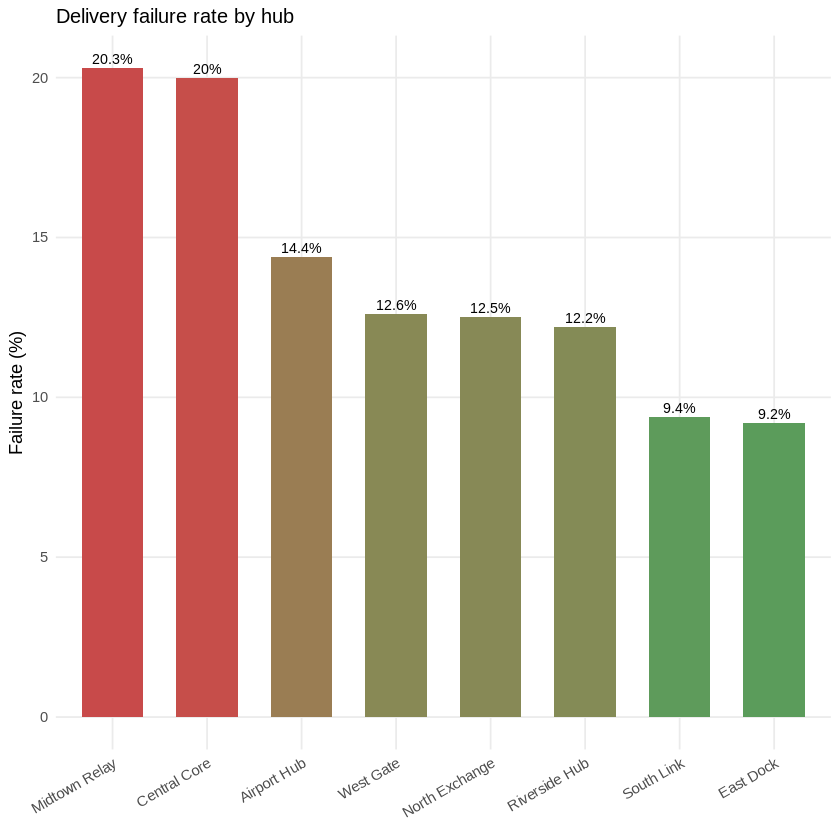

In [ ]:
# chart 1 - hub failure rate
ggplot(q1, aes(x = reorder(hub_name, -pct_failed), y = pct_failed, fill = pct_failed)) +
  geom_col(width = 0.65, show.legend = FALSE) +
  geom_text(aes(label = paste0(pct_failed, "%")), vjust = -0.4, size = 3) +
  scale_fill_gradient(low = "#5b9c5b", high = "#c84a4a") +
  labs(title = "Delivery failure rate by hub", x = NULL, y = "Failure rate (%)") +
  theme_clean +
  theme(axis.text.x = element_text(angle = 30, hjust = 1))

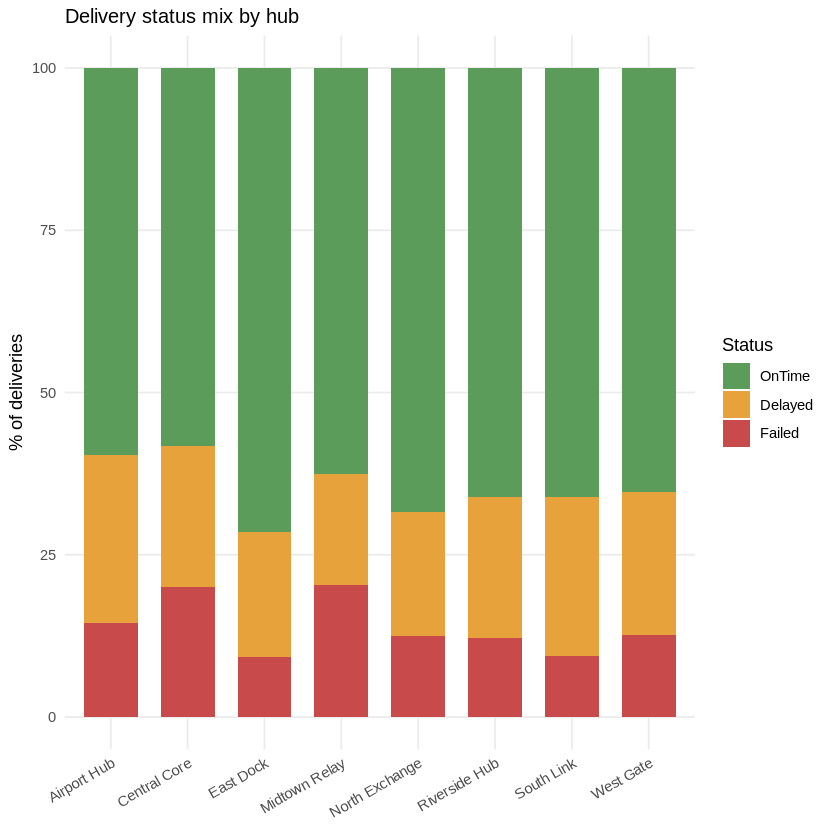

In [ ]:
# chart 2 - delivery status mix by hub (stacked)
hub_status <- deliveries %>%
  inner_join(hubs %>% select(hub_id, hub_name), by = "hub_id") %>%
  group_by(hub_name, delivery_status) %>%
  summarise(n = n(), .groups = "drop") %>%
  group_by(hub_name) %>%
  mutate(pct = n / sum(n) * 100)

hub_status$delivery_status <- factor(hub_status$delivery_status,
                                       levels = c("OnTime","Delayed","Failed"))

ggplot(hub_status, aes(x = hub_name, y = pct, fill = delivery_status)) +
  geom_col(width = 0.7) +
  scale_fill_manual(values = c("OnTime" = "#5b9c5b", "Delayed" = "#e8a23c", "Failed" = "#c84a4a")) +
  labs(title = "Delivery status mix by hub", x = NULL, y = "% of deliveries", fill = "Status") +
  theme_clean +
  theme(axis.text.x = element_text(angle = 30, hjust = 1))

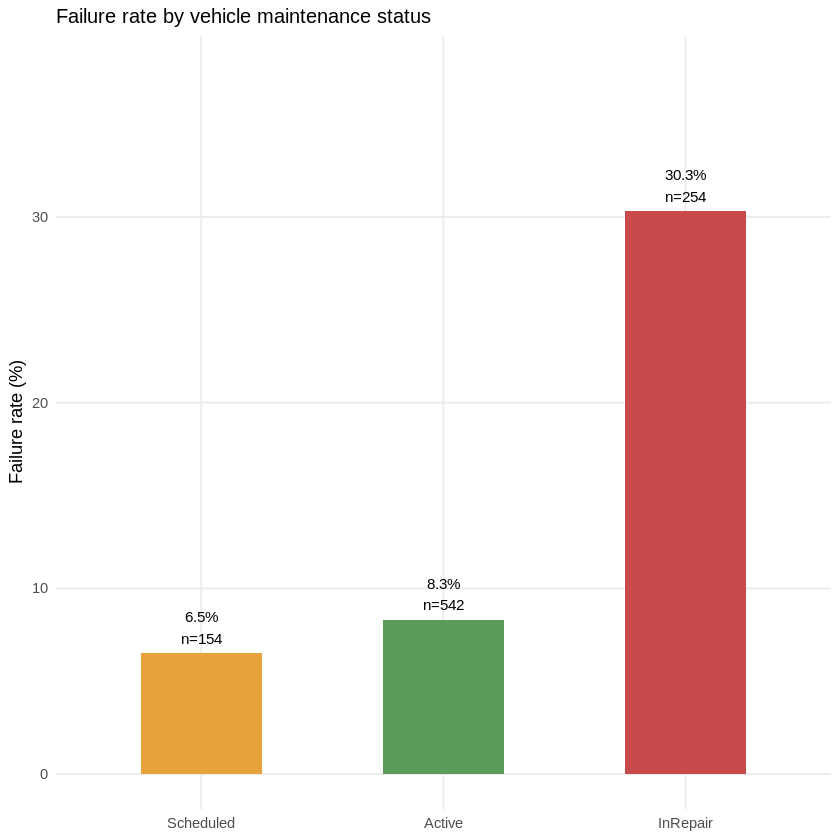

In [ ]:
# chart 3 - failure rate by vehicle maintenance status
maint <- q5 %>%
  group_by(maintenance_status) %>%
  summarise(deliveries = sum(deliveries), failures = sum(failures)) %>%
  mutate(fail_pct = round(failures / deliveries * 100, 1))

maint$maintenance_status <- factor(maint$maintenance_status,
                                     levels = maint$maintenance_status[order(maint$fail_pct)])

ggplot(maint, aes(x = maintenance_status, y = fail_pct, fill = maintenance_status)) +
  geom_col(width = 0.5, show.legend = FALSE) +
  geom_text(aes(label = paste0(fail_pct, "%\nn=", deliveries)), vjust = -0.3, size = 3.2) +
  scale_fill_manual(values = c("Active" = "#5b9c5b", "Scheduled" = "#e8a23c", "InRepair" = "#c84a4a")) +
  labs(title = "Failure rate by vehicle maintenance status", x = NULL, y = "Failure rate (%)") +
  theme_clean +
  ylim(0, max(maint$fail_pct) * 1.25)

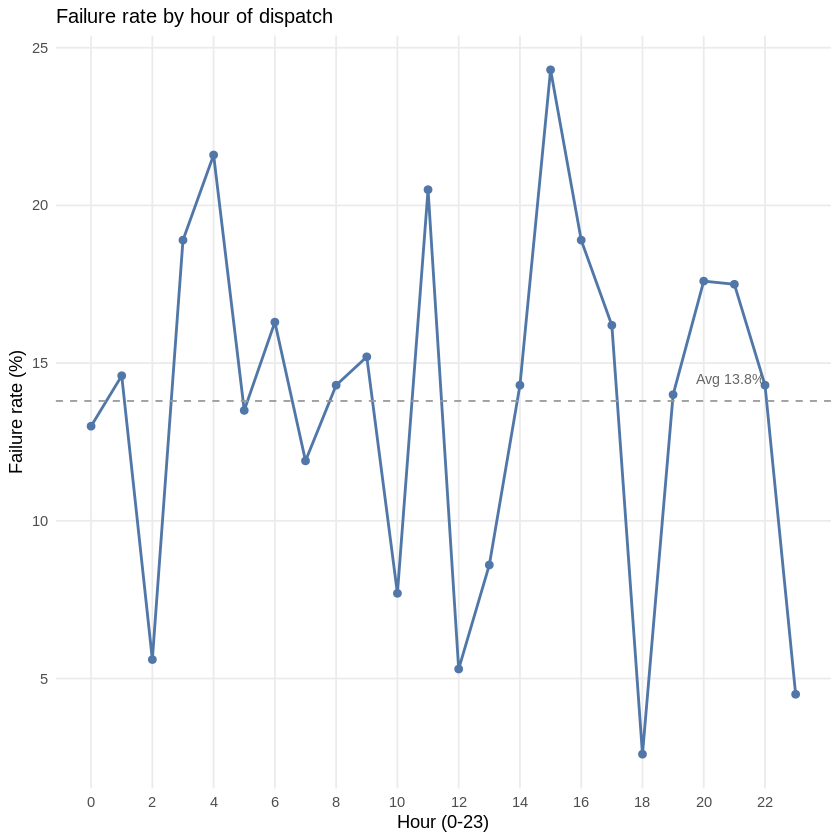

In [ ]:
# chart 4 - hourly failure rate with network average line
ggplot(q11, aes(x = hour, y = fail_pct)) +
  geom_line(colour = "#5077a8", linewidth = 0.8) +
  geom_point(colour = "#5077a8", size = 1.8) +
  geom_hline(yintercept = mean(q11$fail_pct), linetype = "dashed", colour = "#999999") +
  annotate("text", x = 22, y = mean(q11$fail_pct) + 0.7,
           label = sprintf("Avg %.1f%%", mean(q11$fail_pct)),
           colour = "#666666", size = 3, hjust = 1) +
  labs(title = "Failure rate by hour of dispatch",
       x = "Hour (0-23)", y = "Failure rate (%)") +
  scale_x_continuous(breaks = seq(0, 23, 2)) +
  theme_clean

`geom_smooth()` using formula = 'y ~ x'


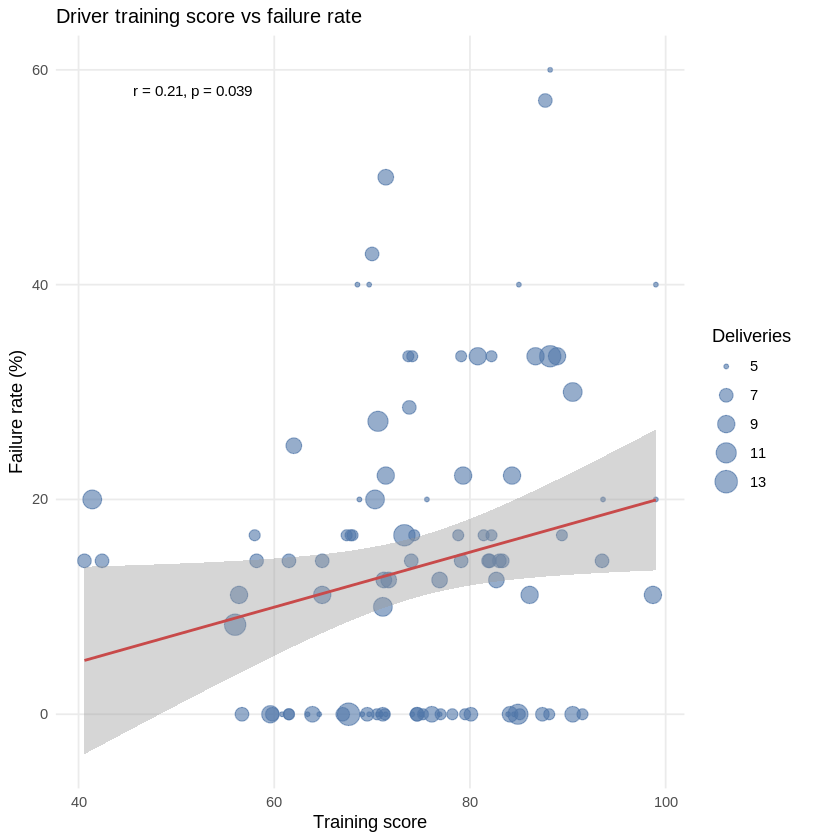

In [ ]:
# chart 5 - training score vs driver failure rate (scatter with regression)
ggplot(drv_summary, aes(x = training_score, y = fail_pct)) +
  geom_point(aes(size = deliveries), colour = "#5077a8", alpha = 0.6) +
  geom_smooth(method = "lm", se = TRUE, colour = "#c84a4a", linewidth = 0.8) +
  annotate("text",
           x = min(drv_summary$training_score) + 5,
           y = max(drv_summary$fail_pct) - 2,
           label = sprintf("r = %.2f, p = %.3f", ct$estimate, ct$p.value),
           hjust = 0, size = 3.2) +
  labs(title = "Driver training score vs failure rate",
       x = "Training score", y = "Failure rate (%)", size = "Deliveries") +
  theme_clean

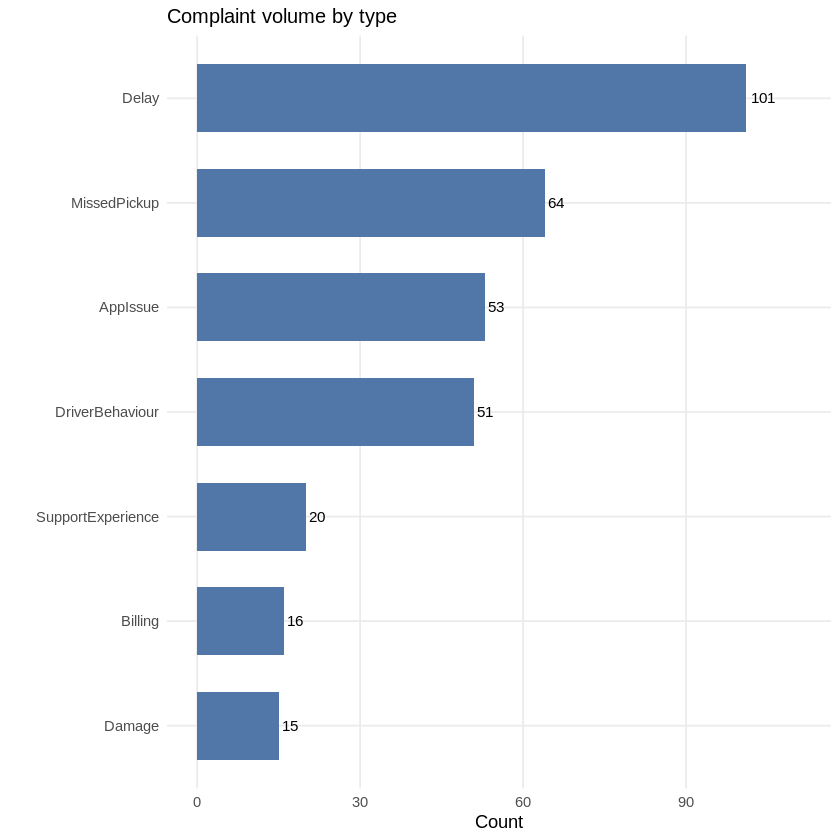

In [ ]:
# chart 6 - complaint volume by type
ct_data <- complaints %>%
  group_by(complaint_type) %>%
  summarise(n = n()) %>%
  arrange(n)
ct_data$complaint_type <- factor(ct_data$complaint_type, levels = ct_data$complaint_type)

ggplot(ct_data, aes(x = complaint_type, y = n)) +
  geom_col(width = 0.65, fill = "#5077a8") +
  geom_text(aes(label = n), hjust = -0.2, size = 3.2) +
  coord_flip() +
  labs(title = "Complaint volume by type", x = NULL, y = "Count") +
  theme_clean +
  expand_limits(y = max(ct_data$n) * 1.1)

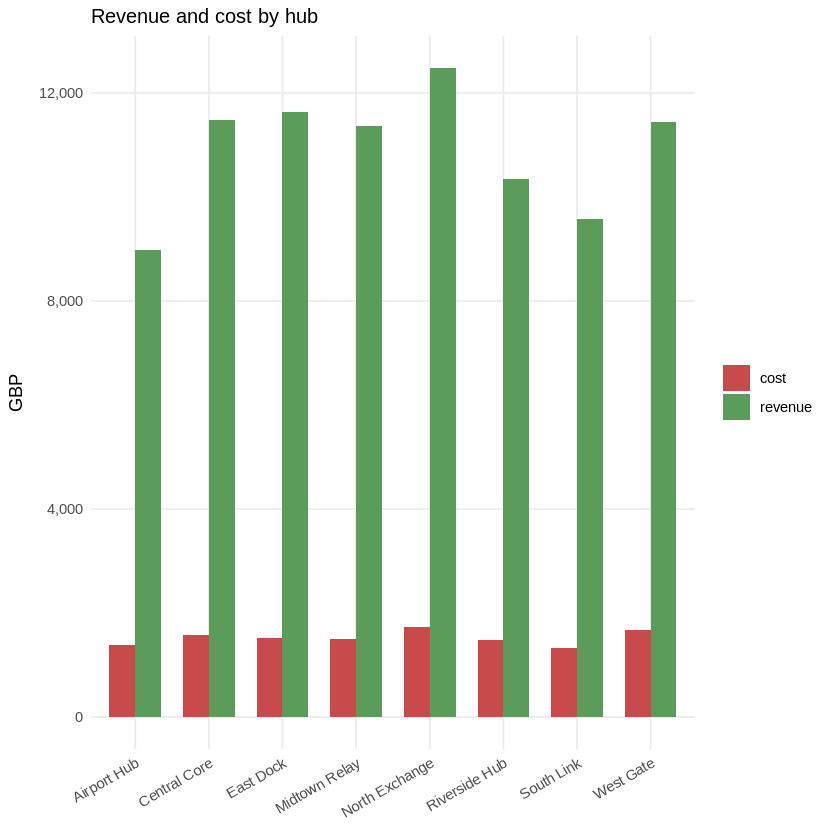

In [ ]:
# chart 7 - revenue vs cost by hub
hubmargin_long <- q8 %>%
  select(hub_name, revenue, cost) %>%
  pivot_longer(cols = c(revenue, cost), names_to = "type", values_to = "value")

ggplot(hubmargin_long, aes(x = hub_name, y = value, fill = type)) +
  geom_col(position = "dodge", width = 0.7) +
  scale_fill_manual(values = c("revenue" = "#5b9c5b", "cost" = "#c84a4a")) +
  scale_y_continuous(labels = label_comma()) +
  labs(title = "Revenue and cost by hub", x = NULL, y = "GBP", fill = NULL) +
  theme_clean +
  theme(axis.text.x = element_text(angle = 30, hjust = 1))

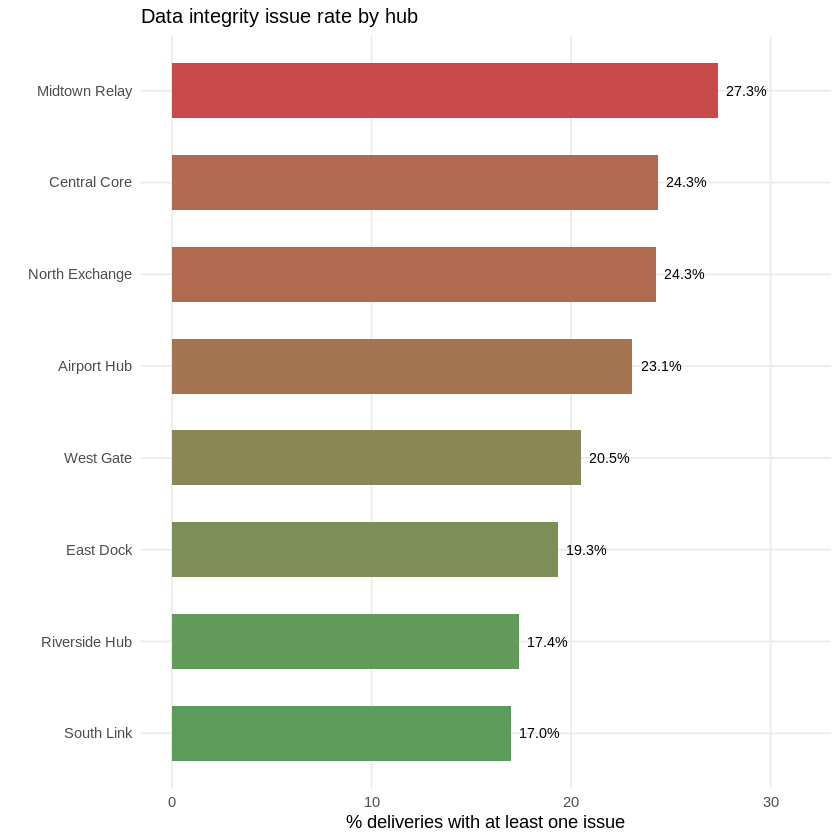

In [ ]:
# chart 8 - data integrity issue rate by hub
ii <- deliveries %>%
  inner_join(hubs %>% select(hub_id, hub_name), by = "hub_id") %>%
  group_by(hub_name) %>%
  summarise(integrity_pct = mean(status_integrity_issue) * 100) %>%
  arrange(integrity_pct)
ii$hub_name <- factor(ii$hub_name, levels = ii$hub_name)

ggplot(ii, aes(x = hub_name, y = integrity_pct, fill = integrity_pct)) +
  geom_col(width = 0.6, show.legend = FALSE) +
  geom_text(aes(label = sprintf("%.1f%%", integrity_pct)), hjust = -0.2, size = 3) +
  coord_flip() +
  scale_fill_gradient(low = "#5b9c5b", high = "#c84a4a") +
  labs(title = "Data integrity issue rate by hub",
       x = NULL, y = "% deliveries with at least one issue") +
  theme_clean +
  expand_limits(y = max(ii$integrity_pct) * 1.15)

## 6. Summary

The SQL queries emerged the key operational issues. The statistical tests verified which ones are genuine:

- **InRepair vehicle dispatch is the single strongest predictor of failure.** The logistic regression isolates it (p < 0.0001) controlling for driver training, employment type, and overrides. About 4.7x the odds of failure.
- **Hub failure rates differ a lot** (9% vs 20%) but delivery duration doesn't differ significantly by hub. So the Central hub problem isn't a speed problem - it's something else (asset quality, dispatch decisions, or zone characteristics).
- **Driver training doesn't predict performance** the way you'd expect - the correlation is weak (r=0.21) and positive, suggesting the training programme isn't well aligned to operational outcomes.
- **Complaint severity is only weakly associated with delivery status** (chi-squared p=0.097), evidence that the complaint and operations systems aren't sharing information.
- **300 orders (24%) never reach the delivery system at all**, concentrated in the API and Web Form booking channels.
- **The financial impact of failures** (wasted fuel + compensation + churn risk) is invisible in normal reporting because it sits across three different systems.

These findings feed directly into the MongoDB design in the next notebook - the case study's problems are about disconnected data sources, and the document model is meant to address that.